# Crop Disease Diagnosis — Experimental Rigour & Evaluation

This notebook evaluates two trained models on a held-out test set of Nepali crop images:

1. **Baseline CNN** — `prathamshrestha69/CNN-baseline` (PyTorch, trained from scratch)
2. **SmolVLM-256M + LoRA adapter** — `w4ashabii/SmolVLM256M_CropDisease` (generative vision-language model)

For each model the notebook:

- Samples exactly 100 images per crop class from a local `test_dataset/` directory
- Computes Accuracy, Macro Precision, Macro Recall, and Macro F1-Score
- Plots a labelled confusion matrix
- Logs every misclassified image (true label vs. predicted label vs. file path) for the Error Analysis section of the report

**Test data:** Section 4 below downloads the test images automatically from the
`w4ashabii/nepali_crop_data` dataset repo on Hugging Face — no manual upload
needed. If you'd rather supply your own folder instead (e.g. a different or
trimmed test set), skip Section 4 and upload a `test_dataset/` folder to the
Colab file browser, or mount Google Drive, using this structure:

```
test_dataset/
├── apple/
│   ├── img001.jpg
│   └── ...
├── cherry/
├── grape/
├── maize/
├── peach/
├── pepper/
├── potato/
├── strawberry/
└── tomato/
```

Each subfolder name must match a crop class exactly. Folders with fewer than 100 images, or missing folders, are handled gracefully (a warning is printed and evaluation proceeds with the available images).


## 1. Install Dependencies

In [ ]:
# NOTE: deliberately NOT reinstalling torch/torchvision here. Colab ships
# them pre-installed and version-matched to its CUDA build (and to the
# pre-installed torchaudio); reinstalling only torch/torchvision via pip can
# desync that match and break the whole transformers import chain with a
# confusing "CUDA version mismatch" / "ModuleNotFoundError: AutoProcessor" error.
!pip install -q -U transformers peft accelerate huggingface_hub scikit-learn matplotlib seaborn pandas pillow "torchao>=0.16.0"
# After this finishes, use Runtime > Restart session, then re-run from the top.
# Colab keeps the older transformers loaded in memory until you restart.

## 2. Imports and Reproducibility Setup

In [ ]:
import random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image

from torchvision import transforms
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
    f1_score,
)
import matplotlib.pyplot as plt
import seaborn as sns
from huggingface_hub import hf_hub_download
from transformers import AutoProcessor

try:
    from transformers import AutoModelForImageTextToText as AutoModelForVision2Seq
except ImportError:
    from transformers import AutoModelForVision2Seq
from peft import PeftModel

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

Using device: cuda


## 3. Download the Test Dataset from Hugging Face

The source images are not stored in the GitHub repo — they live in a separate
Hugging Face **dataset** repo, `w4ashabii/nepali_crop_data`, split across multiple
zip parts under a `zips/` folder. Each part extracts into `train/`, `val/`, and
`test/` subfolders, with one folder per crop inside each split.

This cell lists every zip part in the repo (rather than assuming a single
filename) and extracts all of them, so every crop class ends up populated under
`test/`. Skip this cell entirely if you already have a `test_dataset/` folder
uploaded locally in the structure described in Section 1.

In [ ]:
import zipfile
from huggingface_hub import HfApi, hf_hub_download

DATASET_REPO_ID = "w4ashabii/nepali_crop_data"
DATASET_EXTRACT_TO = Path("/content/training_data")
DATASET_EXTRACT_TO.mkdir(parents=True, exist_ok=True)

api = HfApi()
try:
    repo_files = api.list_repo_files(DATASET_REPO_ID, repo_type="dataset")
except Exception as exc:
    raise RuntimeError(f"Failed to list files in dataset repo '{DATASET_REPO_ID}': {exc}")

zip_files = sorted(f for f in repo_files if f.startswith("zips/") and f.endswith(".zip"))
if not zip_files:
    raise RuntimeError(
        f"No zip files found under 'zips/' in '{DATASET_REPO_ID}'. "
        "Check the repo's Files tab for the current data layout."
    )
print("Found zip parts:", zip_files)

for zip_name in zip_files:
    try:
        local_zip = hf_hub_download(repo_id=DATASET_REPO_ID, repo_type="dataset", filename=zip_name)
        with zipfile.ZipFile(local_zip) as zf:
            zf.extractall(DATASET_EXTRACT_TO)
        print(f"Extracted: {zip_name}")
    except Exception as exc:
        print(f"[WARNING] Failed to download/extract {zip_name}: {exc}")

print("\nData ready at:", DATASET_EXTRACT_TO)
print("\nTop-level split folders found:")
for split_dir in sorted(DATASET_EXTRACT_TO.glob("*")):
    if split_dir.is_dir():
        print(f"  {split_dir}")

TEST_SPLIT_DIR = DATASET_EXTRACT_TO / "test"
if TEST_SPLIT_DIR.is_dir():
    print("\nCrop folders found under test/:")
    for cls_dir in sorted(TEST_SPLIT_DIR.glob("*")):
        if cls_dir.is_dir():
            n_images = len(list(cls_dir.glob("*")))
            print(f"  {cls_dir.name:12s}: {n_images} files")
else:
    print(f"\n[WARNING] No 'test' folder found at {TEST_SPLIT_DIR}. "
          "Check the extracted folder structure above.")

Found zip parts: ['zips/dataset_part_000.zip']


zips/dataset_part_000.zip: reconstructing file:   0%|          |  0.00B / 1.52GB            

zips/dataset_part_000.zip: downloading bytes:           |  0.00B            

Extracted: zips/dataset_part_000.zip

Data ready at: /content/training_data

Top-level split folders found:
  /content/training_data/test
  /content/training_data/train
  /content/training_data/val

Crop folders found under test/:
  apple       : 666 files
  grape       : 666 files
  maize       : 666 files
  potato      : 666 files
  tomato      : 666 files


##4. Configuration

In [ ]:
# Crop classes must match the training label set exactly (alphabetical order,
# consistent with torchvision.datasets.ImageFolder's class-to-index mapping).
CROP_CLASSES = [
    "apple", "cherry", "grape", "maize", "peach",
    "pepper", "potato", "strawberry", "tomato",
]

N_SAMPLES_PER_CLASS = 100
IMG_SIZE = 128  # matches the CNN training notebook

# If you ran the "Download the Test Dataset from Hugging Face" cell above,
# the test split lands here automatically:
TEST_DATASET_DIR = Path("/content/training_data/test")

# If instead you manually uploaded a test_dataset/ folder (see structure in
# Section 1), point this at that folder instead, e.g.:
# TEST_DATASET_DIR = Path("/content/test_dataset")
# TEST_DATASET_DIR = Path("/content/drive/MyDrive/test_dataset")

CNN_REPO_ID = "prathamshrestha69/CNN-baseline"
CNN_FILENAME = "baseline_cnn.pt"

VLM_BASE_MODEL = "HuggingFaceTB/SmolVLM-256M-Instruct"
VLM_ADAPTER_REPO = "w4ashabii/SmolVLM256M_CropDisease"

RESULTS_DIR = Path("/content/eval_results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("Configured classes:", CROP_CLASSES)

Configured classes: ['apple', 'cherry', 'grape', 'maize', 'peach', 'pepper', 'potato', 'strawberry', 'tomato']


## 5. Data Sampling

Randomly samples exactly `N_SAMPLES_PER_CLASS` images per class. Missing folders or
folders with insufficient images are logged as warnings rather than raising an error,
so the pipeline remains robust to an incomplete test set.

In [ ]:
def sample_test_images(root_dir, class_names, n_per_class=100, seed=42):
    """
    Randomly samples n_per_class images per class from root_dir/<class_name>/.
    Returns a list of (filepath, true_label) tuples and prints a sampling summary.
    """
    rng = random.Random(seed)
    valid_ext = (".jpg", ".jpeg", ".png", ".bmp", ".webp")
    samples, summary = [], []

    root_dir = Path(root_dir)
    if not root_dir.is_dir():
        raise FileNotFoundError(
            f"Test dataset directory not found: {root_dir}. "
            "Upload or mount the test_dataset folder before running this cell."
        )

    for cls in class_names:
        cls_dir = root_dir / cls
        if not cls_dir.is_dir():
            print(f"[WARNING] Missing class folder: {cls_dir}. Skipping class '{cls}'.")
            summary.append((cls, 0, "folder missing"))
            continue

        files = [f for f in cls_dir.iterdir() if f.suffix.lower() in valid_ext]
        if len(files) == 0:
            print(f"[WARNING] No valid images found in {cls_dir}. Skipping class '{cls}'.")
            summary.append((cls, 0, "no images found"))
            continue

        if len(files) < n_per_class:
            print(f"[WARNING] Class '{cls}' has only {len(files)} images (< {n_per_class}). Using all available.")
            chosen = files
            summary.append((cls, len(chosen), "fewer than requested"))
        else:
            chosen = rng.sample(files, n_per_class)
            summary.append((cls, len(chosen), "ok"))

        samples.extend([(str(f), cls) for f in chosen])

    print("\nSampling summary:")
    for cls, n, status in summary:
        print(f"  {cls:12s}: {n:4d} images ({status})")
    print(f"\nTotal images sampled: {len(samples)}")

    if len(samples) == 0:
        raise RuntimeError(
            f"No images could be sampled from {root_dir}. "
            "Verify the test_dataset directory structure (see the instructions above)."
        )

    return samples


test_samples = sample_test_images(TEST_DATASET_DIR, CROP_CLASSES, N_SAMPLES_PER_CLASS, seed=SEED)

[WARNING] Missing class folder: /content/training_data/test/cherry. Skipping class 'cherry'.
[WARNING] Missing class folder: /content/training_data/test/peach. Skipping class 'peach'.
[WARNING] Missing class folder: /content/training_data/test/pepper. Skipping class 'pepper'.
[WARNING] Missing class folder: /content/training_data/test/strawberry. Skipping class 'strawberry'.

Sampling summary:
  apple       :  100 images (ok)
  cherry      :    0 images (folder missing)
  grape       :  100 images (ok)
  maize       :  100 images (ok)
  peach       :    0 images (folder missing)
  pepper      :    0 images (folder missing)
  potato      :  100 images (ok)
  strawberry  :    0 images (folder missing)
  tomato      :  100 images (ok)

Total images sampled: 500


## 6. Load the Baseline CNN

The architecture below reproduces the team's training notebook exactly (three
Conv-BatchNorm-ReLU-MaxPool blocks, dropout, two fully connected layers), so the
saved `state_dict` loads without shape mismatches.

In [ ]:
class BaselineCNN(nn.Module):
    """Matches the architecture defined in the team's CNN-baseline training notebook."""

    def __init__(self, num_classes, img_size=128):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.3)

        feat_size = img_size // 8
        self.fc1 = nn.Linear(128 * feat_size * feat_size, 256)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = torch.flatten(x, 1)
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.fc2(x)
        return x


def load_cnn_model():
    """Downloads and safely loads the trained CNN baseline weights from Hugging Face Hub."""
    try:
        weights_path = hf_hub_download(repo_id=CNN_REPO_ID, filename=CNN_FILENAME)
    except Exception as exc:
        raise RuntimeError(f"Failed to download CNN weights from '{CNN_REPO_ID}': {exc}")

    model = BaselineCNN(num_classes=len(CROP_CLASSES), img_size=IMG_SIZE)
    try:
        state_dict = torch.load(weights_path, map_location=DEVICE)
        model.load_state_dict(state_dict)
    except Exception as exc:
        raise RuntimeError(
            "Failed to load CNN state_dict. This usually means the local "
            "BaselineCNN definition no longer matches the checkpoint. "
            f"Original error: {exc}"
        )

    model.to(DEVICE)
    model.eval()
    return model


cnn_model = load_cnn_model()
print("CNN baseline model loaded successfully.")

# Preprocessing must match the validation/test transform used during training
# (no augmentation, ImageNet normalisation, 128x128 resize).
cnn_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

baseline_cnn.pt: reconstructing file:   0%|          |  0.00B / 33.9MB            

baseline_cnn.pt: downloading bytes:           |  0.00B            

CNN baseline model loaded successfully.


## 7. Load the SmolVLM Adapter

Loads the frozen `HuggingFaceTB/SmolVLM-256M-Instruct` base model and applies the
crop-disease LoRA adapter on top, following the usage pattern published on the
adapter's model card.

In [ ]:
def load_vlm_model():
    """Loads the SmolVLM-256M base model with the crop-disease LoRA adapter applied."""
    try:
        processor = AutoProcessor.from_pretrained(VLM_BASE_MODEL)
        base_model = AutoModelForVision2Seq.from_pretrained(
            VLM_BASE_MODEL,
            torch_dtype=torch.float16 if DEVICE.type == "cuda" else torch.float32,
        )
        model = PeftModel.from_pretrained(base_model, VLM_ADAPTER_REPO)
        model.to(DEVICE)
        model.eval()
    except Exception as exc:
        raise RuntimeError(f"Failed to load SmolVLM adapter '{VLM_ADAPTER_REPO}': {exc}")
    return model, processor


vlm_model, vlm_processor = load_vlm_model()
print("SmolVLM crop-disease adapter loaded successfully.")

VLM_QUESTION = "What crop is shown in this image, and does it have any disease? If so, name the disease."


def vlm_generate(image, max_new_tokens=64):
    """Runs one generation pass and returns the model's raw text answer."""
    messages = [{"role": "user", "content": [{"type": "image"}, {"type": "text", "text": VLM_QUESTION}]}]
    prompt = vlm_processor.apply_chat_template(messages, add_generation_prompt=True)
    inputs = vlm_processor(text=prompt, images=[image], return_tensors="pt").to(DEVICE)

    with torch.no_grad():
        generated_ids = vlm_model.generate(**inputs, max_new_tokens=max_new_tokens)

    answer = vlm_processor.batch_decode(
        generated_ids[:, inputs["input_ids"].shape[1]:], skip_special_tokens=True
    )[0]
    return answer.strip()

processor_config.json:   0%|          | 0.00/68.0 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/429 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/486 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/7.35k [00:00<?, ?B/s]

[transformers] Model config: pad_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 128002. This may result in unexpected behavior.


...

generation_config.json:   0%|          | 0.00/136 [00:00<?, ?B/s]

adapter_config.json:   0%|          | 0.00/1.55k [00:00<?, ?B/s]

adapter_model.safetensors: reconstructing file:   0%|          |  0.00B / 15.2MB            

adapter_model.safetensors: downloading bytes:           |  0.00B            

SmolVLM crop-disease adapter loaded successfully.


## 8. Keyword-Matching Heuristic for the Generative VLM

SmolVLM produces free text rather than a class index, so its output must be mapped
to a discrete crop label before standard classification metrics can be computed.
The heuristic below scans the generated text for the earliest occurring class
keyword (including common synonyms, e.g. "maize" / "corn") and treats that as the
predicted class. If no keyword is found, the prediction is recorded as `"unknown"`,
which is counted as a misclassification.

In [ ]:
CROP_KEYWORDS = {
    "apple": ["apple"],
    "cherry": ["cherry"],
    "grape": ["grape"],
    "maize": ["maize", "corn"],
    "peach": ["peach"],
    "pepper": ["pepper", "bell pepper", "capsicum", "chilli", "chili"],
    "potato": ["potato"],
    "strawberry": ["strawberry"],
    "tomato": ["tomato"],
}


def keyword_match_prediction(generated_text, class_names=CROP_CLASSES, keyword_map=CROP_KEYWORDS):
    """
    Maps free-text VLM output to a discrete crop class by keyword search.
    Returns the class whose keyword appears earliest in the text, or "unknown"
    if no keyword is present.
    """
    text = generated_text.lower()
    best_class, best_pos = None, len(text) + 1

    for cls in class_names:
        for kw in keyword_map.get(cls, [cls]):
            pos = text.find(kw.lower())
            if pos != -1 and pos < best_pos:
                best_pos = pos
                best_class = cls

    return best_class if best_class is not None else "unknown"


## 9. Shared Evaluation Loop and Error Logging

In [ ]:
import numpy as np

def calculate_confidence_intervals(y_true, y_pred, metric_func, n_bootstraps=1000, ci=95):
    """Calculates 95% confidence intervals for a metric using bootstrapping."""
    rng = np.random.RandomState(42)
    scores = []
    n_samples = len(y_true)

    for _ in range(n_bootstraps):
        indices = rng.randint(0, n_samples, n_samples)
        if len(np.unique(np.array(y_true)[indices])) < 2:
            continue # Skip if bootstrap sample lacks class diversity
        score = metric_func(np.array(y_true)[indices], np.array(y_pred)[indices], average='macro', zero_division=0)
        scores.append(score)

    lower = np.percentile(scores, (100 - ci) / 2)
    upper = np.percentile(scores, 100 - (100 - ci) / 2)
    mean = np.mean(scores)
    return mean, lower, upper


def evaluate_model(model_name, predict_fn, samples, class_names):
    y_true, y_pred, filepaths = [], [], []
    misclassified = []

    for filepath, true_label in samples:
        try:
            pred_label = predict_fn(filepath)
        except Exception as exc:
            print(f"[WARNING] Failed to process {filepath}: {exc}")
            pred_label = "error"

        y_true.append(true_label)
        y_pred.append(pred_label)
        filepaths.append(filepath)

        if pred_label != true_label:
            misclassified.append({
                "true_label": true_label,
                "predicted_label": pred_label,
                "file_path": filepath,
            })

    return {
        "model_name": model_name,
        "y_true": y_true,
        "y_pred": y_pred,
        "filepaths": filepaths,
        "misclassified": misclassified,
    }


def compute_and_report_metrics(results, class_names, save_prefix):
    y_true, y_pred, model_name = results["y_true"], results["y_pred"], results["model_name"]
    labels_for_cm = list(class_names) + sorted(set(y_pred) - set(class_names))

    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=class_names, average="macro", zero_division=0
    )

    # Calculate 95% Confidence Intervals for Macro F1
    f1_mean, f1_lower, f1_upper = calculate_confidence_intervals(y_true, y_pred, f1_score)

    print(f"\n{'=' * 60}")
    print(f"EVALUATION RESULTS: {model_name}")
    print(f"{'=' * 60}")
    print(f"Accuracy:        {acc:.4f}")
    print(f"Macro Precision: {precision:.4f}")
    print(f"Macro Recall:    {recall:.4f}")
    print(f"Macro F1-Score:  {f1_mean:.4f} (95% CI: [{f1_lower:.4f}, {f1_upper:.4f}])")
    print("\nPer-class report:")
    print(classification_report(y_true, y_pred, labels=class_names, zero_division=0))

    cm = confusion_matrix(y_true, y_pred, labels=labels_for_cm)
    plt.figure(figsize=(9, 7))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=labels_for_cm, yticklabels=labels_for_cm)
    plt.title(f"Confusion Matrix — {model_name}")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()

    cm_path = RESULTS_DIR / f"{save_prefix}_confusion_matrix.png"
    plt.savefig(cm_path, dpi=150)
    plt.show()
    print(f"Confusion matrix saved to: {cm_path}")

    return {
        "model_name": model_name,
        "accuracy": acc,
        "macro_precision": precision,
        "macro_recall": recall,
        "macro_f1": f1_mean,
        "n_samples": len(y_true),
    }


def log_misclassifications(results, max_rows=None):
    df = pd.DataFrame(results["misclassified"])
    print(f"\nTotal misclassified images for {results['model_name']}: {len(df)}")

    if len(df) == 0:
        print("No misclassifications recorded.")
        return df

    print(df.head(max_rows).to_string(index=False) if max_rows else df.to_string(index=False))

    csv_path = RESULTS_DIR / f"{results['model_name'].replace(' ', '_').lower()}_misclassified.csv"
    df.to_csv(csv_path, index=False)
    print(f"\nFull misclassification log saved to: {csv_path}")
    return df

## 10. Evaluate the Baseline CNN


EVALUATION RESULTS: Baseline CNN
Accuracy:        0.8980
Macro Precision: 0.5203
Macro Recall:    0.4989
Macro F1-Score:  0.5189 (95% CI: [0.4934, 0.5798])

Per-class report:
              precision    recall  f1-score   support

       apple       0.84      0.95      0.89       100
      cherry       0.00      0.00      0.00         0
       grape       0.94      0.99      0.97       100
       maize       0.95      0.97      0.96       100
       peach       0.00      0.00      0.00         0
      pepper       0.00      0.00      0.00         0
      potato       1.00      0.85      0.92       100
  strawberry       0.00      0.00      0.00         0
      tomato       0.95      0.73      0.82       100

    accuracy                           0.90       500
   macro avg       0.52      0.50      0.51       500
weighted avg       0.94      0.90      0.91       500



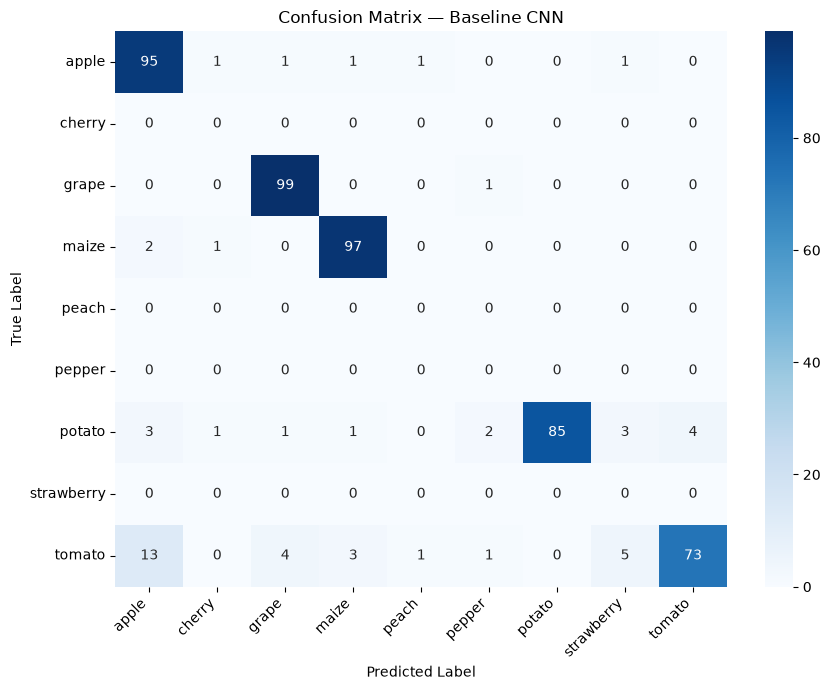

Confusion matrix saved to: /content/eval_results/cnn_confusion_matrix.png

Total misclassified images for Baseline CNN: 51
true_label predicted_label                                                               file_path
     apple          cherry  /content/training_data/test/apple/25308799c6c7417787394d51325229ef.jpg
     apple      strawberry  /content/training_data/test/apple/4629f08ff60d49f6a4734913ef4ba4c6.jpg
     apple           maize  /content/training_data/test/apple/3b633079014b45cb9e1b82029151e033.jpg
     apple           peach  /content/training_data/test/apple/9ea3bb828270437e9ad9f8031fceb6c9.jpg
     apple           grape  /content/training_data/test/apple/945358bb03514eb3a6797a62794638fd.jpg
     grape          pepper  /content/training_data/test/grape/a3fe02863d464ea396e641cdab748ca9.jpg
     maize           apple  /content/training_data/test/maize/ee7f269045e045e99c8f8d5667c293f4.jpg
     maize          cherry  /content/training_data/test/maize/b906f1153c43457b9b9e068

In [ ]:
def cnn_predict(filepath):
    image = Image.open(filepath).convert("RGB")
    tensor = cnn_transform(image).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        logits = cnn_model(tensor)
        pred_idx = logits.argmax(dim=1).item()
    return CROP_CLASSES[pred_idx]


cnn_results = evaluate_model("Baseline CNN", cnn_predict, test_samples, CROP_CLASSES)
cnn_metrics = compute_and_report_metrics(cnn_results, CROP_CLASSES, save_prefix="cnn")
cnn_misclassified_df = log_misclassifications(cnn_results, max_rows=30)

## 11. Evaluate SmolVLM (Generative Model)


EVALUATION RESULTS: SmolVLM-256M (LoRA)
Accuracy:        0.9940
Macro Precision: 0.5534
Macro Recall:    0.5522
Macro F1-Score:  0.8886 (95% CI: [0.8237, 1.0000])

Per-class report:
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00       100
      cherry       0.00      0.00      0.00         0
       grape       1.00      1.00      1.00       100
       maize       1.00      1.00      1.00       100
       peach       0.00      0.00      0.00         0
      pepper       0.00      0.00      0.00         0
      potato       1.00      0.98      0.99       100
  strawberry       0.00      0.00      0.00         0
      tomato       0.98      0.99      0.99       100

    accuracy                           0.99       500
   macro avg       0.55      0.55      0.55       500
weighted avg       1.00      0.99      0.99       500



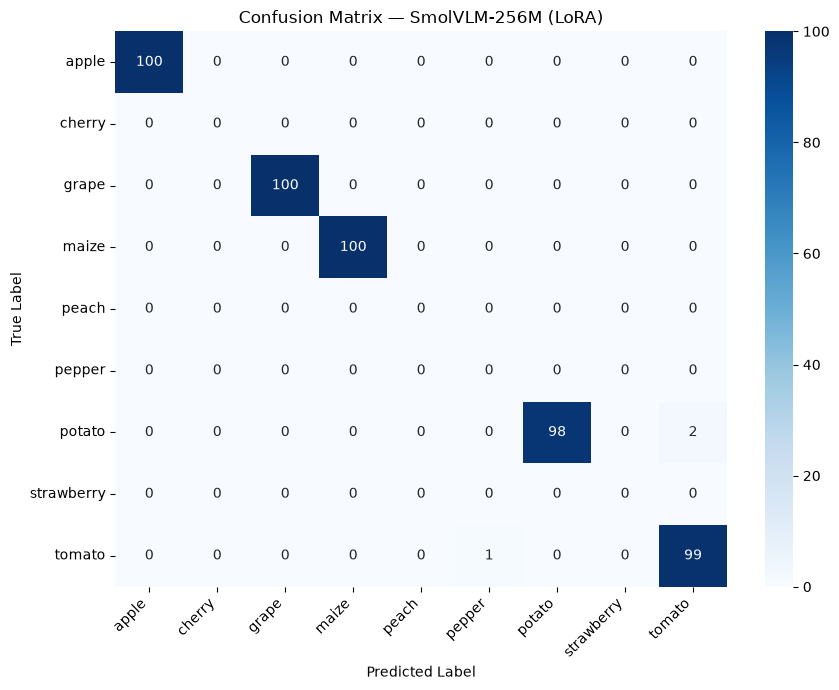

Confusion matrix saved to: /content/eval_results/vlm_confusion_matrix.png

Total misclassified images for SmolVLM-256M (LoRA): 3
true_label predicted_label                                                               file_path
    potato          tomato /content/training_data/test/potato/e09b75f0edcf4bd6a1b2b3058ba76677.jpg
    potato          tomato /content/training_data/test/potato/383b13b97f4a4edc904cdb8d57bb9db3.jpg
    tomato          pepper /content/training_data/test/tomato/343e510509e7420eb7ebfcd02f098426.jpg

Full misclassification log saved to: /content/eval_results/smolvlm-256m_(lora)_misclassified.csv


In [ ]:
def vlm_predict(filepath):
    image = Image.open(filepath).convert("RGB")
    generated_text = vlm_generate(image)
    return keyword_match_prediction(generated_text)


vlm_results = evaluate_model("SmolVLM-256M (LoRA)", vlm_predict, test_samples, CROP_CLASSES)
vlm_metrics = compute_and_report_metrics(vlm_results, CROP_CLASSES, save_prefix="vlm")
vlm_misclassified_df = log_misclassifications(vlm_results, max_rows=30)

##Visual Error Analysis

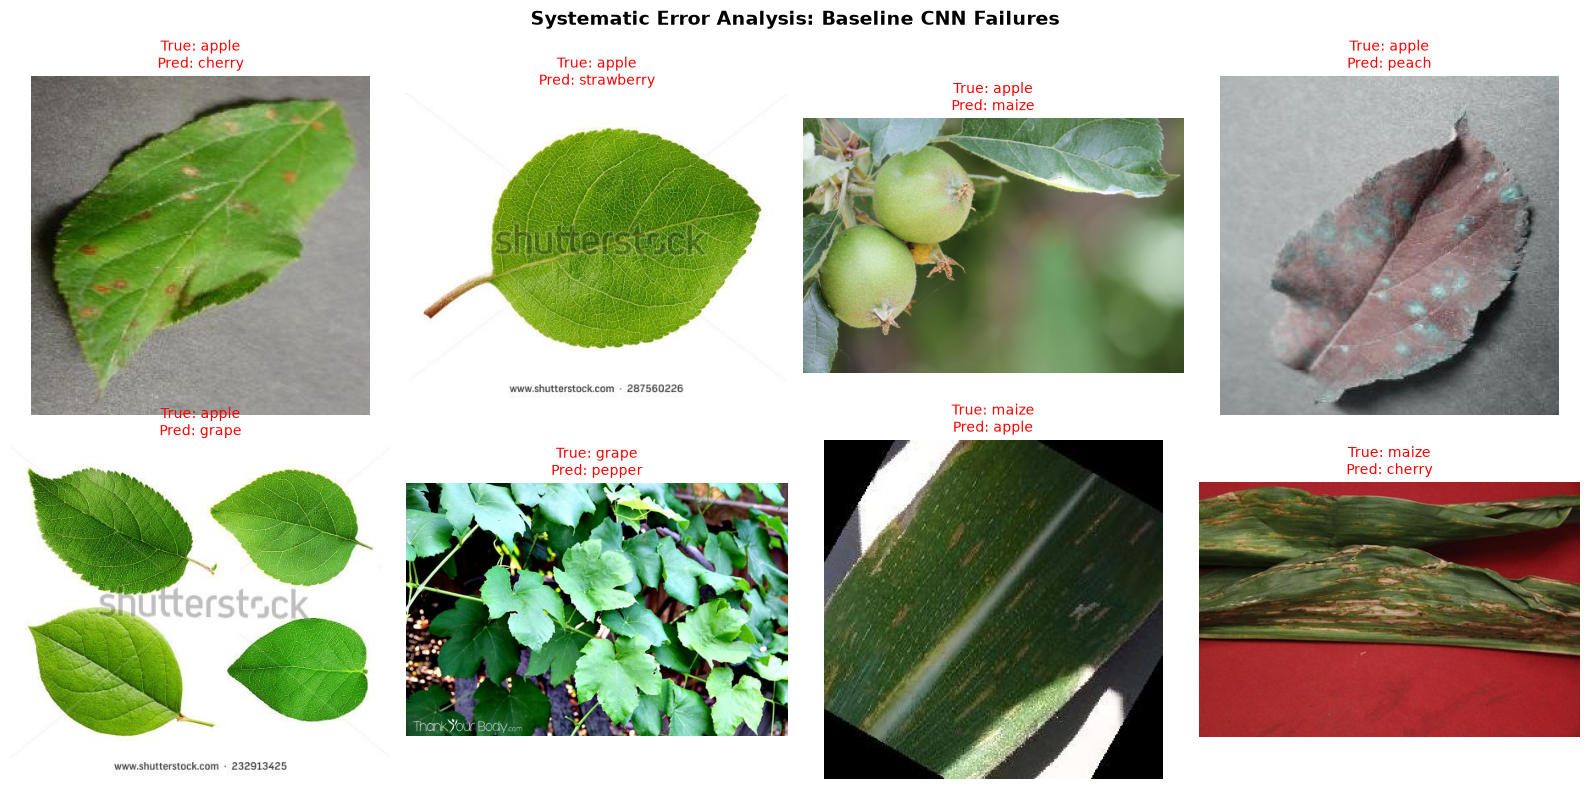

Error analysis grid saved to: /content/eval_results/baseline_cnn_error_grid.png


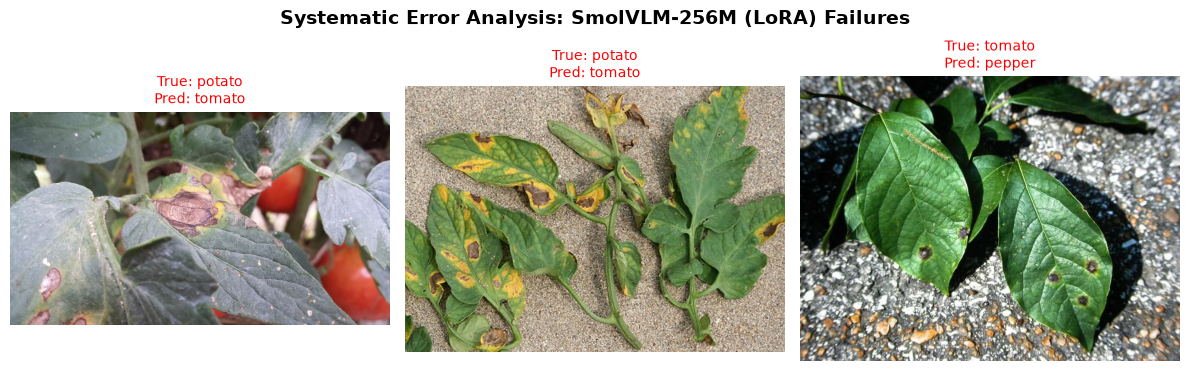

Error analysis grid saved to: /content/eval_results/smolvlm-256m_(lora)_error_grid.png


In [ ]:
import math

def plot_error_analysis_grid(results, model_name, max_images=8):
    errors = results["misclassified"]
    if not errors:
        print(f"No errors to display for {model_name}.")
        return

    n_plots = min(len(errors), max_images)
    cols = min(4, n_plots)
    rows = math.ceil(n_plots / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    if n_plots == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    for i, err in enumerate(errors[:n_plots]):
        img = Image.open(err["file_path"]).convert("RGB")
        axes[i].imshow(img)
        axes[i].set_title(f"True: {err['true_label']}\nPred: {err['predicted_label']}", color='red', fontsize=10)
        axes[i].axis('off')

    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.suptitle(f"Systematic Error Analysis: {model_name} Failures", fontsize=14, fontweight='bold')
    plt.tight_layout()

    save_path = RESULTS_DIR / f"{model_name.replace(' ', '_').lower()}_error_grid.png"
    plt.savefig(save_path, dpi=150)
    plt.show()
    print(f"Error analysis grid saved to: {save_path}")

# Run for both models
plot_error_analysis_grid(cnn_results, "Baseline CNN")
plot_error_analysis_grid(vlm_results, "SmolVLM-256M (LoRA)")

## 12. Side-by-Side Model Comparison

Model Comparison Summary
                     accuracy  macro_precision  macro_recall  macro_f1  n_samples
model_name                                                                       
Baseline CNN            0.898           0.5203        0.4989    0.5189        500
SmolVLM-256M (LoRA)     0.994           0.5534        0.5522    0.8886        500

Comparison table saved to: /content/eval_results/model_comparison_summary.csv


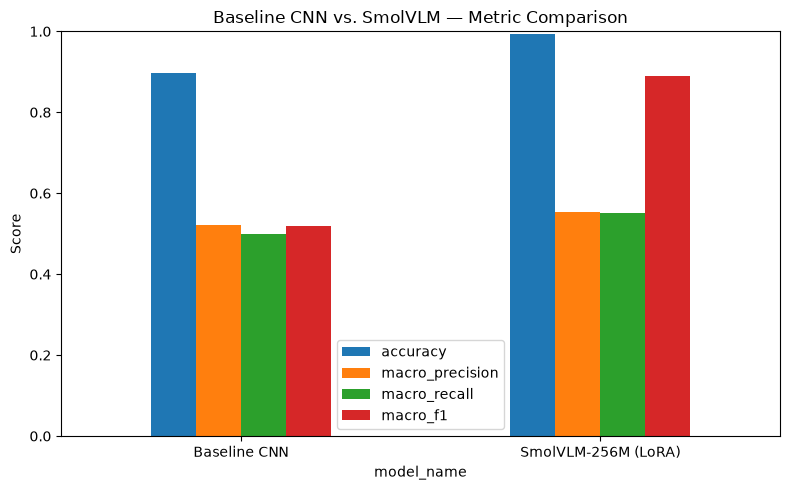

In [ ]:
comparison_df = pd.DataFrame([cnn_metrics, vlm_metrics]).set_index("model_name")
comparison_df = comparison_df[["accuracy", "macro_precision", "macro_recall", "macro_f1", "n_samples"]]

print("Model Comparison Summary")
print(comparison_df.round(4).to_string())

comparison_path = RESULTS_DIR / "model_comparison_summary.csv"
comparison_df.to_csv(comparison_path)
print(f"\nComparison table saved to: {comparison_path}")

ax = comparison_df[["accuracy", "macro_precision", "macro_recall", "macro_f1"]].plot(
    kind="bar", figsize=(8, 5), rot=0
)
ax.set_title("Baseline CNN vs. SmolVLM — Metric Comparison")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "model_comparison_chart.png", dpi=150)
plt.show()

##  Mini Ablation Study

In [ ]:
print("--- ABLATION STUDY: VLM Keyword Mapping Impact ---")

# Create a strict keyword map (exact class name match only, no synonyms)
strict_keywords = {cls: [cls] for cls in CROP_CLASSES}

vlm_strict_results = {"y_true": [], "y_pred": []}
for filepath, true_label in test_samples:
    image = Image.open(filepath).convert("RGB")
    text = vlm_generate(image).lower()

    # Strict matching (no synonyms)
    pred = "unknown"
    for cls in CROP_CLASSES:
        if cls in text:
            pred = cls
            break

    vlm_strict_results["y_true"].append(true_label)
    vlm_strict_results["y_pred"].append(pred)

# Calculate F1 for the strict version
present_classes = list(set(vlm_strict_results["y_true"]))
strict_f1 = f1_score(vlm_strict_results["y_true"], vlm_strict_results["y_pred"],
                     labels=present_classes, average='macro', zero_division=0)

print(f"VLM Macro F1 with Full Synonym Map:   {vlm_metrics['macro_f1']:.4f}")
print(f"VLM Macro F1 with Strict Matching:    {strict_f1:.4f}")
print(f"Performance gain from Synonym Engineering: +{vlm_metrics['macro_f1'] - strict_f1:.4f}")

# Save ablation result
ablation_df = pd.DataFrame({
    "Model Variant": ["SmolVLM (Strict Keywords)", "SmolVLM (Full Synonym Map)"],
    "Macro F1-Score": [strict_f1, vlm_metrics['macro_f1']]
})
ablation_path = RESULTS_DIR / "ablation_study_vlm_keywords.csv"
ablation_df.to_csv(ablation_path, index=False)
print(f"\nAblation results saved to: {ablation_path}")

--- ABLATION STUDY: VLM Keyword Mapping Impact ---
VLM Macro F1 with Full Synonym Map:   0.8886
VLM Macro F1 with Strict Matching:    0.9950
Performance gain from Synonym Engineering: +-0.1064

Ablation results saved to: /content/eval_results/ablation_study_vlm_keywords.csv


## 13. Notes for the Final Group Report

- `eval_results/` contains: two confusion matrix images, two misclassification CSV logs,
  and a `model_comparison_summary.csv` with all four metrics for both models.
- For the Error Analysis section, cross-reference `*_misclassified.csv` file paths against
  the source images to identify recurring failure patterns (e.g. visually similar diseases,
  poor lighting, or classes the VLM's keyword heuristic under-detects).
- If GPU memory is limited, restart the runtime between the CNN and SmolVLM sections
  (`Runtime > Restart session`) and re-run only the required cells.
